In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

#데이터 결로 확인
data_path = os.path.join(os.getcwd(), 'data','A_DeviceMotion_data')
if os.path.exists(data_path):
    print(f"데이터 경로 확인: {data_path}")
else:
    print("경로를 찾을 수 없습니다.")

데이터 경로 확인: /Users/linerenza/Desktop/비정형데이터분석/data/A_DeviceMotion_data


# HAR_TOTAL 데이터 준비

In [2]:
HAR_total = pd.read_csv(data_path + '/HAR_total.csv')
display(HAR_total.head())

,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594


# 통계적 분석 개선

In [3]:
#기준 통계적 분석 결과 데이터 가져오기
HAR_summary = pd.read_csv(data_path +'/HAR_summary.csv' )
display(HAR_summary)

,id,exp_no,activity,maguserAcceleration_mean,maguserAcceleration_min,maguserAcceleration_max,maguserAcceleration_std,maguserAcceleration_skew,magrotationRate_mean,magrotationRate_min,magrotationRate_max,magrotationRate_std,magrotationRate_skew
0,1,1,dws,0.501065,0.045983,1.955246,0.262767,1.139646,2.050740,0.112195,7.138682,1.219460,0.802560
1,1,11,dws,0.508985,0.048613,2.253644,0.279252,1.496823,2.079373,0.158740,6.627259,1.218075,0.725175
2,1,12,ups,0.480549,0.016844,2.163876,0.265723,1.509636,2.474843,0.148675,7.239072,1.302956,0.799158
3,1,13,sit,0.017672,0.001005,0.285272,0.015293,5.197183,0.044123,0.000364,0.926472,0.066350,4.942489
4,1,14,std,0.025681,0.001694,0.146344,0.017401,1.862711,0.078551,0.001511,0.647103,0.075889,2.235072
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,9,5,sit,0.017991,0.001667,0.867065,0.028522,15.153149,0.022275,0.000318,2.478304,0.075582,14.225243
356,9,6,std,0.039642,0.001346,0.341154,0.029047,2.579641,0.100096,0.001592,1.606762,0.124112,3.258141
357,9,7,wlk,0.718710,0.024285,3.360939,0.455437,1.649982,2.057096,0.121499,6.294985,0.962778,0.349034
358,9,8,wlk,0.773928,0.038977,3.746989,0.487419,1.599733,2.156300,0.128250,5.878092,0.966396,0.401792


In [4]:
print(HAR_summary.columns)

Index(['id', 'exp_no', 'activity', 'maguserAcceleration_mean',
       'maguserAcceleration_min', 'maguserAcceleration_max',
       'maguserAcceleration_std', 'maguserAcceleration_skew',
       'magrotationRate_mean', 'magrotationRate_min', 'magrotationRate_max',
       'magrotationRate_std', 'magrotationRate_skew'],
      dtype='object')


In [5]:
# 변화량 기반 통계 추가 (시간 변화 반영)
har_summary_extend = (
    HAR_total
    .groupby(['id', 'exp_no', 'activity'])
    .agg(
        # 변화량
        magAcc_diff_mean=('maguserAcceleration', lambda x: np.mean(np.abs(np.diff(x)))),
        magAcc_diff_std=('maguserAcceleration', lambda x: np.std(np.diff(x))),

        # rotation도 동일하게
        magRot_diff_mean=('magrotationRate', lambda x: np.mean(np.abs(np.diff(x)))),
        magRot_diff_std=('magrotationRate', lambda x: np.std(np.diff(x))),
    )
    .reset_index()
)
display(har_summary_extend.head())
print('data shape:', har_summary_extend.shape)

,id,exp_no,activity,magAcc_diff_mean,magAcc_diff_std,magRot_diff_mean,magRot_diff_std
0,1,1,dws,0.156223,0.225879,0.549250,0.729892
1,1,2,dws,0.172652,0.264766,0.561417,0.766130
2,1,3,ups,0.106623,0.160714,0.353279,0.485297
3,1,4,ups,0.106893,0.169816,0.379859,0.543572
4,1,5,sit,0.005342,0.009997,0.010980,0.022569


data shape: (360, 7)


In [6]:
#기존 통계적 분석 결과와 병합
har_summary_extend = pd.merge(
    HAR_summary,
    har_summary_extend,
    on=['id', 'exp_no', 'activity'],
    how='left'
)
display(har_summary_extend.head())

,id,exp_no,activity,maguserAcceleration_mean,maguserAcceleration_min,maguserAcceleration_max,maguserAcceleration_std,maguserAcceleration_skew,magrotationRate_mean,magrotationRate_min,magrotationRate_max,magrotationRate_std,magrotationRate_skew,magAcc_diff_mean,magAcc_diff_std,magRot_diff_mean,magRot_diff_std
0,1,1,dws,0.501065,0.045983,1.955246,0.262767,1.139646,2.050740,0.112195,7.138682,1.219460,0.802560,0.156223,0.225879,0.549250,0.729892
1,1,11,dws,0.508985,0.048613,2.253644,0.279252,1.496823,2.079373,0.158740,6.627259,1.218075,0.725175,0.183215,0.269536,0.567549,0.763912
2,1,12,ups,0.480549,0.016844,2.163876,0.265723,1.509636,2.474843,0.148675,7.239072,1.302956,0.799158,0.148390,0.222556,0.517058,0.691436
3,1,13,sit,0.017672,0.001005,0.285272,0.015293,5.197183,0.044123,0.000364,0.926472,0.066350,4.942489,0.005342,0.009997,0.010980,0.022569
4,1,14,std,0.025681,0.001694,0.146344,0.017401,1.862711,0.078551,0.001511,0.647103,0.075889,2.235072,0.006663,0.010225,0.014726,0.025161


In [7]:
#har_summary_extend의 컬럼명 확인
print("har_summary_extend columns:", har_summary_extend.columns)

har_summary_extend columns: Index(['id', 'exp_no', 'activity', 'maguserAcceleration_mean',
       'maguserAcceleration_min', 'maguserAcceleration_max',
       'maguserAcceleration_std', 'maguserAcceleration_skew',
       'magrotationRate_mean', 'magrotationRate_min', 'magrotationRate_max',
       'magrotationRate_std', 'magrotationRate_skew', 'magAcc_diff_mean',
       'magAcc_diff_std', 'magRot_diff_mean', 'magRot_diff_std'],
      dtype='object')


In [8]:
data_save_path = os.path.join(data_path + '/Extra_analysis')
#결과 저장
csv_path = f"{data_save_path}/har_summary_final.csv"
pkl_path = f"{data_save_path}/har_summary_final.pkl"

har_summary_extend.to_csv(csv_path, index=False)
har_summary_extend.to_pickle(pkl_path)

print("저장 완료")

저장 완료


# PEAK 분석 개선

In [9]:
#기준 peak 분석 데이터
peak_df = pd.read_csv(data_path + '/HAR_peak_Analysis.csv')
display(peak_df.head())

,sequence_key,exp_no,id,activity,f_n_rot,p_interval_rot,p_interval_std_rot,p_mean_rot,p_max_rot,p_min_rot,...,p_mean_acc,p_max_acc,p_min_acc,p_std_acc,cfa,p_diff_mean_acc,p_interval_cv_acc,p_large_ratio_acc,peak_count_ratio_acc_rot,peak_amp_ratio_acc_rot
0,exp_1_id_1_dws,1,1,dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,...,0.000000,0.000000,0.000000,0.000000,3.456021,0.000000,0.000000,0.00,0.014706,0.000000
1,exp_1_id_2_dws,1,2,dws,84,25.469880,17.956816,4.694013,6.100538,4.004648,...,0.000000,0.000000,0.000000,0.000000,6.235781,0.000000,0.000000,0.00,0.011765,0.000000
2,exp_1_id_3_dws,1,3,dws,1,0.000000,0.000000,4.187099,4.187099,4.187099,...,0.000000,0.000000,0.000000,0.000000,4.508070,0.000000,0.000000,0.00,0.500000,0.000000
3,exp_1_id_4_dws,1,4,dws,171,11.200000,8.752075,5.305817,11.627792,4.018219,...,5.056741,6.446061,4.270856,0.983082,6.019406,0.725069,1.242402,0.25,0.029070,0.953056
4,exp_1_id_5_dws,1,5,dws,2,308.000000,0.000000,4.505965,4.936863,4.075067,...,0.000000,0.000000,0.000000,0.000000,5.413530,0.000000,0.000000,0.00,0.333333,0.000000


In [10]:
peak_df.columns

Index(['sequence_key', 'exp_no', 'id', 'activity', 'f_n_rot', 'p_interval_rot',
       'p_interval_std_rot', 'p_mean_rot', 'p_max_rot', 'p_min_rot',
       'p_std_rot', 'cfr', 'p_diff_mean_rot', 'p_interval_cv_rot',
       'p_large_ratio_rot', 'f_n_acc', 'p_interval_acc', 'p_interval_std_acc',
       'p_mean_acc', 'p_max_acc', 'p_min_acc', 'p_std_acc', 'cfa',
       'p_diff_mean_acc', 'p_interval_cv_acc', 'p_large_ratio_acc',
       'peak_count_ratio_acc_rot', 'peak_amp_ratio_acc_rot'],
      dtype='object')

In [11]:
from scipy.signal import find_peaks

# peak 찾는 함수

def peak_table(signal, threshold=4.0, distance=1, top_n=None):
    # signal에서 threshold 이상인 peak를 찾고
    # peak 위치와 높이를 dataframe으로 반환
    signal = np.asarray(signal, dtype=float)
    #threshold 이상인 피크의 위치 와 높이 추출
    peak_idx, props = find_peaks(signal, height=threshold, distance=distance)

    peaks = pd.DataFrame({
        "peak_height" : props['peak_heights'],
        "peak_index" : peak_idx
    }).sort_values("peak_height", ascending = False)

    return peaks.head(top_n) if top_n else peaks



# crest factor 함수
def crest_factor(x):
    """신호에서 “얼마나 큰 피크(튀는 값)가 있는지”를 보는 지표"""
    # RMS (root mean square) 계산
    values = np.asarray(x, dtype=float)
    rms = np.sqrt(np.mean(values ** 2))

    # RMS가 0이면 0, 아니면 최대 절댓값 / RMS 반환
    if rms == 0:
        return 0.0
    return float(np.max(np.abs(values)) / rms)



# peak analysis
feature_rows = []

for (exp_no, sid, activity), group in HAR_total.groupby(["exp_no", "id", "activity"], sort=True):
    # ---------------------------------
    # rotation magnitude 추출
    # ---------------------------------
    signal_rot = group["magrotationRate"].to_numpy(dtype=float)

    # rotation signal에서 peak 찾기
    peaks_rot = peak_table(signal_rot, threshold=4.0)

    peak_pos_rot = np.sort(peaks_rot["peak_index"].to_numpy()) if len(peaks_rot) else np.array([])
    peak_val_rot = peaks_rot["peak_height"].to_numpy(dtype=float) if len(peaks_rot) else np.array([])
    intervals_rot = np.diff(peak_pos_rot) if len(peaks_rot) >= 2 else np.array([])

    # ---------------------------------
    # acceleration magnitude 추출
    # ---------------------------------
    signal_acc = group["maguserAcceleration"].to_numpy(dtype=float)

    # acceleration signal에서 peak 찾기
    peaks_acc = peak_table(signal_acc, threshold=4.0)

    peak_pos_acc = np.sort(peaks_acc["peak_index"].to_numpy()) if len(peaks_acc) else np.array([])
    peak_val_acc = peaks_acc["peak_height"].to_numpy(dtype=float) if len(peaks_acc) else np.array([])
    intervals_acc = np.diff(peak_pos_acc) if len(peaks_acc) >= 2 else np.array([])

    # ---------------------------------
    # rotation peak 특징
    # ---------------------------------
    row = {
        # 기본 정보
        "sequence_key": f"exp_{exp_no}_id_{sid}_{activity}",
        "exp_no": exp_no,
        "id": sid,
        "activity": activity,

        # =========================
        # rotation peak 특징
        # =========================
        "f_n_rot": int(len(peaks_rot)),  # rotation 피크 개수

        "p_interval_rot": float(intervals_rot.mean()) if len(intervals_rot) else 0.0,  # rotation 피크 간격 평균
        "p_interval_std_rot": float(intervals_rot.std(ddof=1)) if len(intervals_rot) >= 2 else 0.0,  # rotation 피크 간격 표준편차

        "p_mean_rot": float(peak_val_rot.mean()) if len(peak_val_rot) else 0.0,  # rotation 피크 높이 평균
        "p_max_rot": float(peak_val_rot.max()) if len(peak_val_rot) else 0.0,    # rotation 피크 최대값
        "p_min_rot": float(peak_val_rot.min()) if len(peak_val_rot) else 0.0,    # rotation 피크 최소값
        "p_std_rot": float(peak_val_rot.std(ddof=1)) if len(peak_val_rot) >= 2 else 0.0,  # rotation 피크 높이 표준편차

        "cfr": crest_factor(signal_rot),  # rotation crest factor

        # 피크 높이 변화량
        "p_diff_mean_rot": float(np.mean(np.abs(np.diff(peak_val_rot)))) if len(peak_val_rot) >= 2 else 0.0,

        # 피크 간격의 규칙성 (작을수록 규칙적)
        "p_interval_cv_rot": float(intervals_rot.std(ddof=1) / (intervals_rot.mean() + 1e-6)) if len(intervals_rot) >= 2 else 0.0,

        # 평균보다 큰 피크 비율
        "p_large_ratio_rot": float(np.sum(peak_val_rot > peak_val_rot.mean()) / len(peak_val_rot)) if len(peak_val_rot) > 0 else 0.0,
    }

    # ---------------------------------
    # acceleration peak 특징 추가
    # ---------------------------------
    row.update({
        "f_n_acc": int(len(peaks_acc)),  # acceleration 피크 개수

        "p_interval_acc": float(intervals_acc.mean()) if len(intervals_acc) else 0.0,  # acceleration 피크 간격 평균
        "p_interval_std_acc": float(intervals_acc.std(ddof=1)) if len(intervals_acc) >= 2 else 0.0,  # acceleration 피크 간격 표준편차

        "p_mean_acc": float(peak_val_acc.mean()) if len(peak_val_acc) else 0.0,  # acceleration 피크 높이 평균
        "p_max_acc": float(peak_val_acc.max()) if len(peak_val_acc) else 0.0,    # acceleration 피크 최대값
        "p_min_acc": float(peak_val_acc.min()) if len(peak_val_acc) else 0.0,    # acceleration 피크 최소값
        "p_std_acc": float(peak_val_acc.std(ddof=1)) if len(peak_val_acc) >= 2 else 0.0,  # acceleration 피크 높이 표준편차

        "cfa": crest_factor(signal_acc),  # acceleration crest factor

        # 피크 높이 변화량
        "p_diff_mean_acc": float(np.mean(np.abs(np.diff(peak_val_acc)))) if len(peak_val_acc) >= 2 else 0.0,

        # 피크 간격의 규칙성
        "p_interval_cv_acc": float(intervals_acc.std(ddof=1) / (intervals_acc.mean() + 1e-6)) if len(intervals_acc) >= 2 else 0.0,


        # 평균보다 큰 피크 비율
        "p_large_ratio_acc": float(np.sum(peak_val_acc > peak_val_acc.mean()) / len(peak_val_acc)) if len(peak_val_acc) > 0 else 0.0,
    })

    # ---------------------------------
    # rotation / acceleration 비교 특징
    # ---------------------------------
    row.update({
        # acceleration 피크 개수와 rotation 피크 개수 비율
        "peak_count_ratio_acc_rot": (len(peaks_acc) + 1) / (len(peaks_rot) + 1),

        # acceleration 평균 피크 높이와 rotation 평균 피크 높이 비율
        "peak_amp_ratio_acc_rot": (peak_val_acc.mean() + 1e-6) / (peak_val_rot.mean() + 1e-6)
        if len(peak_val_acc) > 0 and len(peak_val_rot) > 0 else 0.0,
    })

    feature_rows.append(row)



# dataframe으로 변환
peak_final = pd.DataFrame(feature_rows)



# 컬럼 순서 정리
peak_final = peak_final[
    [
        "sequence_key", "exp_no", "id", "activity",

        # rotation
        "f_n_rot", "p_interval_rot", "p_interval_std_rot",
        "p_mean_rot", "p_max_rot", "p_min_rot", "p_std_rot",
        "cfr", "p_diff_mean_rot", "p_interval_cv_rot", "p_large_ratio_rot",

        # acceleration
        "f_n_acc", "p_interval_acc", "p_interval_std_acc",
        "p_mean_acc", "p_max_acc", "p_min_acc", "p_std_acc",
        "cfa", "p_diff_mean_acc", "p_interval_cv_acc", "p_large_ratio_acc",

        # 비교
        "peak_count_ratio_acc_rot", "peak_amp_ratio_acc_rot"
    ]
]

# 결과 확인

print("peak_final shape:", peak_final.shape)
display(peak_final.head())

peak_final shape: (360, 28)


,sequence_key,exp_no,id,activity,f_n_rot,p_interval_rot,p_interval_std_rot,p_mean_rot,p_max_rot,p_min_rot,...,p_mean_acc,p_max_acc,p_min_acc,p_std_acc,cfa,p_diff_mean_acc,p_interval_cv_acc,p_large_ratio_acc,peak_count_ratio_acc_rot,peak_amp_ratio_acc_rot
0,exp_1_id_1_dws,1,1,dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,...,0.000000,0.000000,0.000000,0.000000,3.456021,0.000000,0.000000,0.00,0.014706,0.000000
1,exp_1_id_2_dws,1,2,dws,84,25.469880,17.956816,4.694013,6.100538,4.004648,...,0.000000,0.000000,0.000000,0.000000,6.235781,0.000000,0.000000,0.00,0.011765,0.000000
2,exp_1_id_3_dws,1,3,dws,1,0.000000,0.000000,4.187099,4.187099,4.187099,...,0.000000,0.000000,0.000000,0.000000,4.508070,0.000000,0.000000,0.00,0.500000,0.000000
3,exp_1_id_4_dws,1,4,dws,171,11.200000,8.752075,5.305817,11.627792,4.018219,...,5.056741,6.446061,4.270856,0.983082,6.019406,0.725069,1.242402,0.25,0.029070,0.953056
4,exp_1_id_5_dws,1,5,dws,2,308.000000,0.000000,4.505965,4.936863,4.075067,...,0.000000,0.000000,0.000000,0.000000,5.413530,0.000000,0.000000,0.00,0.333333,0.000000


In [12]:
# peak 분석 columns 확인
print("peak_final columns:", peak_final.columns)

peak_final columns: Index(['sequence_key', 'exp_no', 'id', 'activity', 'f_n_rot', 'p_interval_rot',
       'p_interval_std_rot', 'p_mean_rot', 'p_max_rot', 'p_min_rot',
       'p_std_rot', 'cfr', 'p_diff_mean_rot', 'p_interval_cv_rot',
       'p_large_ratio_rot', 'f_n_acc', 'p_interval_acc', 'p_interval_std_acc',
       'p_mean_acc', 'p_max_acc', 'p_min_acc', 'p_std_acc', 'cfa',
       'p_diff_mean_acc', 'p_interval_cv_acc', 'p_large_ratio_acc',
       'peak_count_ratio_acc_rot', 'peak_amp_ratio_acc_rot'],
      dtype='object')


In [13]:
data_save_path = os.path.join(data_path + '/Extra_analysis')
#결과 저장
csv_path = f"{data_save_path}/peak_final.csv"
pkl_path = f"{data_save_path}/peak_final.pkl"

peak_final.to_csv(csv_path, index=False)
peak_final.to_pickle(pkl_path)

print("저장 완료")

저장 완료


## peak 분석만 사용하고 모델 검증

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
# 클래스 비율을 유지하는 10-fold 교차검증 설정
feature_cols = [ "f_n_rot", "p_interval_rot", "p_interval_std_rot",
    "p_mean_rot", "p_max_rot", "p_min_rot", "p_std_rot",
    "cfr", "p_diff_mean_rot", "p_interval_cv_rot", "p_large_ratio_rot",
    "f_n_acc", "p_interval_acc", "p_interval_std_acc",
    "p_mean_acc", "p_max_acc", "p_min_acc", "p_std_acc",
    "cfa", "p_diff_mean_acc", "p_interval_cv_acc", "p_large_ratio_acc",
    "peak_count_ratio_acc_rot", "peak_amp_ratio_acc_rot"
]

# 결측치는 0으로 채워 학습용 행렬 생성
X = peak_final[feature_cols].fillna(0.0)

# 예측 대상은 activity 라벨
y = peak_final["activity"]

# 랜덤포레스트 분류기 생성
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# 클래스 비율을 유지하는 10-fold 교차검증 설정
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# 각 fold의 accuracy 계산
accuracy = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("mean accuracy:", accuracy.mean())
print("std:", accuracy.std(ddof=1))
print(f"Number of sequences: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")

mean accuracy: 0.6888888888888889
std: 0.08156561313164902
Number of sequences: 360
Number of features: 24


# Change Point 분석 개선

In [15]:
# 기준 change point 분석 데이터
CP_data = pd.read_csv(data_path + '/HAR_CP_Analysis.csv')
display(CP_data)

,id,exp_no,activity,cp1,cp2,cp3,cp4,cp5,cp6
0,1,1,dws,0,0,1,5,3,3
1,1,11,dws,0,0,2,1,3,3
2,1,12,ups,3,0,2,5,3,3
3,1,13,sit,0,0,216,141,3,3
4,1,14,std,0,0,49,24,3,3
...,...,...,...,...,...,...,...,...,...
355,9,5,sit,0,0,214,125,3,3
356,9,6,std,0,0,215,134,3,3
357,9,7,wlk,3,1,8,10,3,3
358,9,8,wlk,0,0,1,3,3,3


In [16]:
print(CP_data.nunique()) 

id           24
exp_no       15
activity      6
cp1          20
cp2           5
cp3         111
cp4         106
cp5           1
cp6           1
dtype: int64


In [17]:
import pickle
import ruptures as rpt

# 데이터 로그
# HAR_total.pkl 파일을 불러와서 har_data로 저장
har_total_path = os.path.join(data_path, "HAR_total.pkl")

if os.path.exists(har_total_path):
    with open(har_total_path, "rb") as f:
        har_data = pickle.load(f)
    print("HAR_total.pkl 파일이 성공적으로 로드되었습니다.")
else:
    print("HAR_total.pkl 파일을 찾을 수 없습니다.")

display(har_data.head())


#데이터 타입 정리
# id, exp_no를 문자열로 맞춤
har_data["id"] = har_data["id"].astype(str)
har_data["exp_no"] = har_data["exp_no"].astype(str)


# change point 분석 준비
# 실험 단위별로 묶어서 change point 분석
experiments = har_data.groupby(["id", "exp_no", "activity"])
ch_pt_results = []

# change point 분석 반복
for (subject_id, exp_no, activity), group_data in experiments:

    # 한국 주석:
    # 회전 magnitude, 가속도 magnitude 추출
    mag_rotation = group_data["magrotationRate"].to_numpy(dtype=float)
    mag_acceleration = group_data["maguserAcceleration"].to_numpy(dtype=float)

    try:
        # ==========================================
        # (1) 평균 변화 기반 change point
        # ==========================================
        # 평균이 바뀌는 지점을 찾음
        algo_mean = rpt.Binseg(model="l2", min_size=10, jump=5)

        cp_mean_rot_points = algo_mean.fit(mag_rotation).predict(pen=20)
        cp_mean_acc_points = algo_mean.fit(mag_acceleration).predict(pen=20)

        # 마지막 끝점 포함되므로 -1
        cp_mean_rot = len(cp_mean_rot_points) - 1
        cp_mean_acc = len(cp_mean_acc_points) - 1


        # ==========================================
        # (2) 분산 변화 기반 change point
        # ==========================================
        # 분산이 바뀌는 지점을 찾음
        algo_var = rpt.Binseg(model="normal", min_size=10, jump=5)

        cp_var_rot_points = algo_var.fit(mag_rotation).predict(pen=20)
        cp_var_acc_points = algo_var.fit(mag_acceleration).predict(pen=20)

        cp_var_rot = len(cp_var_rot_points) - 1
        cp_var_acc = len(cp_var_acc_points) - 1


        # ==========================================
        # (3) 기울기 변화 기반 change point
        # ==========================================
        # linear 모델은 2차원 입력 필요
        # [시간축, 신호값] 형태로 만듦
        n_rot = len(mag_rotation)
        n_acc = len(mag_acceleration)

        signal_rot_2d = np.column_stack((np.arange(n_rot), mag_rotation))
        signal_acc_2d = np.column_stack((np.arange(n_acc), mag_acceleration))

        algo_slope = rpt.Binseg(model="linear", min_size=10, jump=5)

        # 원래 n_bkps=3 쓰면 거의 항상 3이 나와서
        # penalty 방식으로 바꿔서 데이터마다 다르게 나오게 함
        cp_slope_rot_points = algo_slope.fit(signal_rot_2d).predict(pen=20)
        cp_slope_acc_points = algo_slope.fit(signal_acc_2d).predict(pen=20)

        cp_slope_rot = len(cp_slope_rot_points) - 1
        cp_slope_acc = len(cp_slope_acc_points) - 1


        # ==========================================
        # (4) 추가 변수: 구간 길이 정보
        # ==========================================
        # 평균 변화 기준 change point 위치로 구간 길이 계산
        seg_rot = np.diff([0] + cp_mean_rot_points)
        seg_acc = np.diff([0] + cp_mean_acc_points)

        cp_len_mean_rot = float(np.mean(seg_rot)) if len(seg_rot) > 0 else 0.0
        cp_len_std_rot = float(np.std(seg_rot, ddof=1)) if len(seg_rot) >= 2 else 0.0
        cp_len_max_rot = float(np.max(seg_rot)) if len(seg_rot) > 0 else 0.0

        cp_len_mean_acc = float(np.mean(seg_acc)) if len(seg_acc) > 0 else 0.0
        cp_len_std_acc = float(np.std(seg_acc, ddof=1)) if len(seg_acc) >= 2 else 0.0
        cp_len_max_acc = float(np.max(seg_acc)) if len(seg_acc) > 0 else 0.0


        # ==========================================
        # (5) 결과 저장
        # ==========================================
        ch_pt_results.append({
            "sequence_key": f"exp_{exp_no}_id_{subject_id}_{activity}",
            "id": subject_id,
            "exp_no": exp_no,
            "activity": activity,

            # 평균 기반 변화점 개수
            "cp1": cp_mean_rot,   # rotation 평균 변화점 개수
            "cp2": cp_mean_acc,   # acceleration 평균 변화점 개수

            # 분산 기반 변화점 개수
            "cp3": cp_var_rot,    # rotation 분산 변화점 개수
            "cp4": cp_var_acc,    # acceleration 분산 변화점 개수

            # 기울기 기반 변화점 개수
            "cp5": cp_slope_rot,  # rotation 기울기 변화점 개수
            "cp6": cp_slope_acc,  # acceleration 기울기 변화점 개수

            # 추가 변수: 평균 기반 구간 길이
            "cp_len_mean_rot": cp_len_mean_rot,
            "cp_len_std_rot": cp_len_std_rot,
            "cp_len_max_rot": cp_len_max_rot,

            "cp_len_mean_acc": cp_len_mean_acc,
            "cp_len_std_acc": cp_len_std_acc,
            "cp_len_max_acc": cp_len_max_acc,
        })

    except Exception as e:
        print(f"Error in id={subject_id}, exp_no={exp_no}, activity={activity}: {e}")
        continue


# dataframe으로 변환
ch_pt = pd.DataFrame(ch_pt_results)

# 컬럼 순서 정리
ch_pt = ch_pt[
    [
        "sequence_key", "id", "exp_no", "activity",
        "cp1", "cp2", "cp3", "cp4", "cp5", "cp6",
        "cp_len_mean_rot", "cp_len_std_rot", "cp_len_max_rot",
        "cp_len_mean_acc", "cp_len_std_acc", "cp_len_max_acc"
    ]
]

# 결과 확인
print("ch_pt shape:", ch_pt.shape)
display(ch_pt.head())

HAR_total.pkl 파일이 성공적으로 로드되었습니다.


,Unnamed: 0,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,exp_no,id,activity,maguserAcceleration,magrotationRate
0,0,-2.116381,-1.077507,-2.261502,-0.404768,0.880780,0.245713,-1.264215,-1.027909,-0.947909,0.282683,-0.254346,-0.407670,11,12,dws,0.557491,1.885038
1,1,-2.148154,-1.049759,-2.284278,-0.417081,0.867303,0.271686,-1.162024,-0.269118,-0.848823,0.256712,0.079154,-0.560291,11,12,dws,0.621363,1.463976
2,2,-2.153824,-1.026749,-2.297008,-0.432082,0.855621,0.284961,-0.665042,0.520170,-0.726722,0.253600,0.346680,-0.463275,11,12,dws,0.631762,1.113994
3,3,-2.142509,-1.012749,-2.290595,-0.445311,0.848291,0.286507,-0.079809,0.055322,-0.604534,0.411818,0.459372,-0.510293,11,12,dws,0.800635,0.612284
4,4,-2.130486,-1.007262,-2.274149,-0.452661,0.845372,0.283600,0.456097,-0.186877,-0.441315,0.311594,0.477305,-0.925049,11,12,dws,1.086566,0.661594


/Users/linerenza/Library/Python/3.9/lib/python/site-packages/ruptures/costs/costnormal.py:28: UserWarning: New behaviour in v1.1.5: a small bias is added to the covariance matrix to cope with truly constant segments (see PR#198).
  warnings.warn(


ch_pt shape: (360, 16)


,sequence_key,id,exp_no,activity,cp1,cp2,cp3,cp4,cp5,cp6,cp_len_mean_rot,cp_len_std_rot,cp_len_max_rot,cp_len_mean_acc,cp_len_std_acc,cp_len_max_acc
0,exp_1_id_1_dws,1,1,dws,0,0,1,5,149,150,1751.0,0.000000,1751.0,1751.0,0.0,1751.0
1,exp_11_id_1_dws,1,11,dws,0,0,2,1,78,79,896.0,0.000000,896.0,896.0,0.0,896.0
2,exp_12_id_1_ups,1,12,ups,3,0,2,5,91,91,266.5,443.586519,930.0,1066.0,0.0,1066.0
3,exp_13_id_1_sit,1,13,sit,0,0,216,141,898,896,10292.0,0.000000,10292.0,10292.0,0.0,10292.0
4,exp_14_id_1_std,1,14,std,0,0,49,24,219,217,2553.0,0.000000,2553.0,2553.0,0.0,2553.0


In [18]:
# change point 분석  columns 확인
print("ch_pt columns:", ch_pt.columns)

ch_pt columns: Index(['sequence_key', 'id', 'exp_no', 'activity', 'cp1', 'cp2', 'cp3', 'cp4',
       'cp5', 'cp6', 'cp_len_mean_rot', 'cp_len_std_rot', 'cp_len_max_rot',
       'cp_len_mean_acc', 'cp_len_std_acc', 'cp_len_max_acc'],
      dtype='object')


In [19]:
# id 및 exp_no를 int로 변환 (원래는 문자열이었지만, 분석 편의를 위해 숫자로 바꿈)
ch_pt['id'] = ch_pt['id'].astype(int)
ch_pt['exp_no'] = ch_pt['exp_no'].astype(int)

In [20]:
print(ch_pt.nunique())

sequence_key       360
id                  24
exp_no              15
activity             6
cp1                 20
cp2                  5
cp3                111
cp4                106
cp5                269
cp6                283
cp_len_mean_rot    356
cp_len_std_rot     178
cp_len_max_rot     338
cp_len_mean_acc    352
cp_len_std_acc      44
cp_len_max_acc     350
dtype: int64


In [21]:
data_save_path = os.path.join(data_path + '/Extra_analysis')
#결과 저장
csv_path = f"{data_save_path}/har_ch_final.csv"
pkl_path = f"{data_save_path}/har_ch_final.pkl"

ch_pt.to_csv(csv_path, index=False)
ch_pt.to_pickle(pkl_path)

print("저장 완료")

저장 완료


In [22]:
# 1. 데이터 로드
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# 데이터 로드

# 특징 및 타겟 분리
X = ch_pt[['cp1', 'cp2', 'cp3', 'cp4','cp5','cp6','cp_len_mean_rot', 'cp_len_std_rot', 'cp_len_max_rot',
       'cp_len_mean_acc', 'cp_len_std_acc', 'cp_len_max_acc']].values
y = ch_pt['activity'].values
le = LabelEncoder()
y = le.fit_transform(y)
groups = ch_pt['id'].astype(str).values

# 2. GroupShuffleSplit으로 학습/테스트 분할 (누출 방지)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# 3. 표준화 (선형 모델 사용 시)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# 모델 불러오기
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 모델 정의
models = {
    'RF': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ),

    'XGB': XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        random_state=42
    ),

    'LGBM': LGBMClassifier(
        n_estimators=400,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity = -1
    )
}

# 교차검증 설정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

best_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_name]
best_model.fit(X_train, y_train)

print(f"\n최고 모델: {best_name} (정확도: {cv_scores[best_name]:.3f})")


RF: 0.646 (+/- 0.064)
XGB: 0.646 (+/- 0.063)


/Users/linerenza/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/linerenza/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/linerenza/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/linerenza/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/linerenza/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMCla

LGBM: 0.642 (+/- 0.060)

최고 모델: RF (정확도: 0.646)


# 통계적 분석, peak 분석, change point 분석 결과 합치기


In [24]:
#통계적 분석, peak 분석, change point 분석 결과를 모두 합쳐서 최종 데이터프레임 생성
pd.set_option('display.max_columns', None) # 모든 컬럼이 보이도록 설정
final_df = har_summary_extend.merge(peak_final, on=[ "id", "exp_no", "activity"], how="left")
final_df = final_df.merge(ch_pt, on=["id", "exp_no", "activity"], how="left")   
display(final_df.head())
print("final_df shape:", final_df.shape)

,id,exp_no,activity,maguserAcceleration_mean,maguserAcceleration_min,maguserAcceleration_max,maguserAcceleration_std,maguserAcceleration_skew,magrotationRate_mean,magrotationRate_min,magrotationRate_max,magrotationRate_std,magrotationRate_skew,magAcc_diff_mean,magAcc_diff_std,magRot_diff_mean,magRot_diff_std,sequence_key_x,f_n_rot,p_interval_rot,p_interval_std_rot,p_mean_rot,p_max_rot,p_min_rot,p_std_rot,cfr,p_diff_mean_rot,p_interval_cv_rot,p_large_ratio_rot,f_n_acc,p_interval_acc,p_interval_std_acc,p_mean_acc,p_max_acc,p_min_acc,p_std_acc,cfa,p_diff_mean_acc,p_interval_cv_acc,p_large_ratio_acc,peak_count_ratio_acc_rot,peak_amp_ratio_acc_rot,sequence_key_y,cp1,cp2,cp3,cp4,cp5,cp6,cp_len_mean_rot,cp_len_std_rot,cp_len_max_rot,cp_len_mean_acc,cp_len_std_acc,cp_len_max_acc
0,1,1,dws,0.501065,0.045983,1.955246,0.262767,1.139646,2.050740,0.112195,7.138682,1.219460,0.802560,0.156223,0.225879,0.549250,0.729892,exp_1_id_1_dws,67,25.909091,18.497174,4.821695,7.138682,4.013819,0.571169,2.992226,0.047346,0.713926,0.402985,0,0.0,0.0,0.0,0.0,0.0,0.0,3.456021,0.0,0.0,0.0,0.014706,0.0,exp_1_id_1_dws,0,0,1,5,149,150,1751.0,0.000000,1751.0,1751.0,0.0,1751.0
1,1,11,dws,0.508985,0.048613,2.253644,0.279252,1.496823,2.079373,0.158740,6.627259,1.218075,0.725175,0.183215,0.269536,0.567549,0.763912,exp_11_id_1_dws,38,23.513514,19.184226,4.653541,6.627259,4.004458,0.636398,2.750435,0.070887,0.815881,0.368421,0,0.0,0.0,0.0,0.0,0.0,0.0,3.882361,0.0,0.0,0.0,0.025641,0.0,exp_11_id_1_dws,0,0,2,1,78,79,896.0,0.000000,896.0,896.0,0.0,896.0
2,1,12,ups,0.480549,0.016844,2.163876,0.265723,1.509636,2.474843,0.148675,7.239072,1.302956,0.799158,0.148390,0.222556,0.517058,0.691436,exp_12_id_1_ups,50,20.795918,16.332457,5.185460,7.239072,4.041368,0.833111,2.588530,0.065259,0.785368,0.420000,0,0.0,0.0,0.0,0.0,0.0,0.0,3.941039,0.0,0.0,0.0,0.019608,0.0,exp_12_id_1_ups,3,0,2,5,91,91,266.5,443.586519,930.0,1066.0,0.0,1066.0
3,1,13,sit,0.017672,0.001005,0.285272,0.015293,5.197183,0.044123,0.000364,0.926472,0.066350,4.942489,0.005342,0.009997,0.010980,0.022569,exp_13_id_1_sit,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.627549,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,0.0,12.206843,0.0,0.0,0.0,1.000000,0.0,exp_13_id_1_sit,0,0,216,141,898,896,10292.0,0.000000,10292.0,10292.0,0.0,10292.0
4,1,14,std,0.025681,0.001694,0.146344,0.017401,1.862711,0.078551,0.001511,0.647103,0.075889,2.235072,0.006663,0.010225,0.014726,0.025161,exp_14_id_1_std,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.925252,0.000000,0.000000,0.000000,0,0.0,0.0,0.0,0.0,0.0,0.0,4.717860,0.0,0.0,0.0,1.000000,0.0,exp_14_id_1_std,0,0,49,24,219,217,2553.0,0.000000,2553.0,2553.0,0.0,2553.0


final_df shape: (360, 55)


In [25]:
#final_df 데이터 저장
data_save_path = os.path.join(data_path + '/Extra_analysis')
csv_path = f"{data_save_path}/final_df.csv"
pkl_path = f"{data_save_path}/final_df.pkl" 

final_df.to_csv(csv_path, index=False)
final_df.to_pickle(pkl_path)
print("저장 완료")

저장 완료


In [26]:
print("final_df shape:", final_df.shape)
print("final_df columns:", final_df.columns)

final_df shape: (360, 55)
final_df columns: Index(['id', 'exp_no', 'activity', 'maguserAcceleration_mean',
       'maguserAcceleration_min', 'maguserAcceleration_max',
       'maguserAcceleration_std', 'maguserAcceleration_skew',
       'magrotationRate_mean', 'magrotationRate_min', 'magrotationRate_max',
       'magrotationRate_std', 'magrotationRate_skew', 'magAcc_diff_mean',
       'magAcc_diff_std', 'magRot_diff_mean', 'magRot_diff_std',
       'sequence_key_x', 'f_n_rot', 'p_interval_rot', 'p_interval_std_rot',
       'p_mean_rot', 'p_max_rot', 'p_min_rot', 'p_std_rot', 'cfr',
       'p_diff_mean_rot', 'p_interval_cv_rot', 'p_large_ratio_rot', 'f_n_acc',
       'p_interval_acc', 'p_interval_std_acc', 'p_mean_acc', 'p_max_acc',
       'p_min_acc', 'p_std_acc', 'cfa', 'p_diff_mean_acc', 'p_interval_cv_acc',
       'p_large_ratio_acc', 'peak_count_ratio_acc_rot',
       'peak_amp_ratio_acc_rot', 'sequence_key_y', 'cp1', 'cp2', 'cp3', 'cp4',
       'cp5', 'cp6', 'cp_len_mean_rot', 'cp

In [27]:
# final_df 수치형 변수들을 list로 추출
numeric_cols = final_df.select_dtypes(include=[np.number]).columns.tolist()
print("final_df numeric columns:", numeric_cols)

categorical_cols = final_df.select_dtypes(include=['object']).columns.tolist()
print("final_df categorical columns:", categorical_cols)


final_df numeric columns: ['id', 'exp_no', 'maguserAcceleration_mean', 'maguserAcceleration_min', 'maguserAcceleration_max', 'maguserAcceleration_std', 'maguserAcceleration_skew', 'magrotationRate_mean', 'magrotationRate_min', 'magrotationRate_max', 'magrotationRate_std', 'magrotationRate_skew', 'magAcc_diff_mean', 'magAcc_diff_std', 'magRot_diff_mean', 'magRot_diff_std', 'f_n_rot', 'p_interval_rot', 'p_interval_std_rot', 'p_mean_rot', 'p_max_rot', 'p_min_rot', 'p_std_rot', 'cfr', 'p_diff_mean_rot', 'p_interval_cv_rot', 'p_large_ratio_rot', 'f_n_acc', 'p_interval_acc', 'p_interval_std_acc', 'p_mean_acc', 'p_max_acc', 'p_min_acc', 'p_std_acc', 'cfa', 'p_diff_mean_acc', 'p_interval_cv_acc', 'p_large_ratio_acc', 'peak_count_ratio_acc_rot', 'peak_amp_ratio_acc_rot', 'cp1', 'cp2', 'cp3', 'cp4', 'cp5', 'cp6', 'cp_len_mean_rot', 'cp_len_std_rot', 'cp_len_max_rot', 'cp_len_mean_acc', 'cp_len_std_acc', 'cp_len_max_acc']
final_df categorical columns: ['activity', 'sequence_key_x', 'sequence_key_

In [28]:
#drop sequence_key 컬럼은 분석에 필요 없어서 제거
final_df = final_df.drop(columns=["sequence_key_x", "sequence_key_y"])
final_df.head()
print("final_df shape:", final_df.shape)

final_df shape: (360, 53)


In [29]:
# final_df의 통계 요약 정보 확인
display(final_df.describe())
#final_df에 결측치가 있는지 확인
print("final_df 결측치 개수:")
null_counts = final_df.isnull().sum()
null_counts = null_counts[null_counts > 0]

if len(null_counts) > 0:
    print("결측치가 있는 변수\n:")
    display(null_counts)
else:
    print("결측치 없음\n")
    
#final_df에 change point 분석에 cp1~cp6에 unique한 값이 몇 개인지 확인
print("final_df change point 분석 cp1~cp6 unique 값 개수:")
print(final_df[['cp1', 'cp2', 'cp3', 'cp4', 'cp5', 'cp6']].nunique())  

,id,exp_no,maguserAcceleration_mean,maguserAcceleration_min,maguserAcceleration_max,maguserAcceleration_std,maguserAcceleration_skew,magrotationRate_mean,magrotationRate_min,magrotationRate_max,magrotationRate_std,magrotationRate_skew,magAcc_diff_mean,magAcc_diff_std,magRot_diff_mean,magRot_diff_std,f_n_rot,p_interval_rot,p_interval_std_rot,p_mean_rot,p_max_rot,p_min_rot,p_std_rot,cfr,p_diff_mean_rot,p_interval_cv_rot,p_large_ratio_rot,f_n_acc,p_interval_acc,p_interval_std_acc,p_mean_acc,p_max_acc,p_min_acc,p_std_acc,cfa,p_diff_mean_acc,p_interval_cv_acc,p_large_ratio_acc,peak_count_ratio_acc_rot,peak_amp_ratio_acc_rot,cp1,cp2,cp3,cp4,cp5,cp6,cp_len_mean_rot,cp_len_std_rot,cp_len_max_rot,cp_len_mean_acc,cp_len_std_acc,cp_len_max_acc
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.00000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,12.500000,8.400000,0.564737,0.032054,2.997426,0.344710,2.967832,1.686898,0.096892,5.852997,0.861426,2.210682,0.199270,0.325643,0.437396,0.613545,97.705556,53.388940,43.647329,3.276574,5.202701,2.656741,0.517933,5.737258,0.045228,0.514677,0.257156,7.625000,68.086992,40.90180,1.428650,1.742100,1.271973,0.136047,6.476846,0.044975,0.172487,0.100516,0.418761,0.266614,1.958333,0.175000,46.883333,31.655556,339.394444,340.244444,2690.617335,687.997523,3443.472222,3614.994815,276.932783,3824.738889
std,6.931821,4.750722,0.472382,0.036854,2.262085,0.281308,3.829570,1.214126,0.093275,4.089110,0.589493,3.388018,0.194477,0.302357,0.397066,0.557291,174.088816,141.866891,129.098027,2.457932,4.718216,1.937503,0.625823,6.427684,0.105927,0.469534,0.207583,25.078394,216.582838,162.85898,2.191260,2.780730,1.944500,0.302602,5.946881,0.141278,0.364306,0.189435,0.458453,0.413465,3.507404,0.558487,81.294867,48.298609,247.799395,247.749258,2750.574130,1270.860428,2837.631237,2817.655780,939.345954,2838.904013
min,1.000000,1.000000,0.007415,0.000118,0.031555,0.002884,-0.790553,0.005706,0.000018,0.091228,0.007510,-0.334010,0.001463,0.002003,0.001575,0.002448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.756173,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.860383,0.000000,0.000000,0.000000,0.002404,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,30.000000,53.857143,0.000000,115.000000,240.000000,0.000000,377.000000
25%,6.750000,4.000000,0.081042,0.004140,1.101039,0.044940,1.453569,0.179782,0.002428,2.821323,0.221957,0.528311,0.009396,0.024907,0.028312,0.068825,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.579198,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.892053,0.000000,0.000000,0.000000,0.025576,0.000000,0.000000,0.000000,2.000000,4.000000,163.000000,163.500000,741.833333,0.000000,1352.500000,1716.000000,0.000000,1800.500000
50%,12.500000,8.000000,0.501043,0.023455,2.699034,0.314928,2.028387,1.880921,0.079752,5.403497,0.931467,0.818728,0.162391,0.279392,0.362087,0.496743,19.000000,10.800513,7.256588,4.452569,5.403497,4.003548,0.340697,3.010190,0.017618,0.601558,0.355270,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,4.703134,0.000000,0.000000,0.000000,0.170666,0.000000,0.000000,0.000000,7.000000,11.000000,256.500000,257.000000,1796.000000,0.000000,2526.000000,2753.000000,0.000000,2910.000000
75%,18.250000,13.000000,0.769332,0.040052,4.267664,0.491287,2.859846,2.437587,0.139879,8.015754,1.234051,2.256982,0.255946,0.450926,0.633873,0.877398,119.250000,33.885621,23.839829,4.940997,8.015754,4.016113,0.758544

final_df 결측치 개수:
결측치 없음

final_df change point 분석 cp1~cp6 unique 값 개수:
cp1     20
cp2      5
cp3    111
cp4    106
cp5    269
cp6    283
dtype: int64


## 데이터 전처리

In [30]:
#데이터 전처리
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# 특징 및 타겟 분리
feature_cols = [col for col in final_df.columns if col not in ['id','exp_no', 'activity']]
X = final_df[feature_cols].values
y = final_df['activity'].values
le = LabelEncoder()
y = le.fit_transform(y)
groups = final_df['id'].astype(str).values

# 2. GroupShuffleSplit으로 학습/테스트 분할 (누출 방지)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# 3. 표준화 (선형 모델 사용 시)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 모델 설정

In [31]:
# 모델 불러오기
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 모델 정의
models = {
    'RF': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ),

    'XGB': XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        random_state=42
    ),

    'LGBM': LGBMClassifier(
        n_estimators=400,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity = -1
    )
}


In [32]:
# warnings 무시
import warnings
warnings.filterwarnings("ignore")

In [33]:
# 모델 평가
# 교차검증 설정
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

best_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_name]
best_model.fit(X_train, y_train)

print(f"\n최고 모델: {best_name} (정확도: {cv_scores[best_name]:.3f})")


RF: 0.877 (+/- 0.025)
XGB: 0.863 (+/- 0.013)
LGBM: 0.898 (+/- 0.032)

최고 모델: LGBM (정확도: 0.898)


In [34]:
# 필요한 평가 함수 불러오기
from sklearn.metrics import (
    accuracy_score,        # 정확도
    f1_score,              # F1-score
    classification_report,# 상세 리포트
    ConfusionMatrixDisplay
)

# 예측
y_pred = best_model.predict(X_test)

# 성능 계산
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

# 결과 출력
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1-Score: {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.800
Macro F1-Score: 0.810

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.53      0.70        15
           1       0.59      1.00      0.74        10
           2       1.00      0.90      0.95        10
           3       0.91      1.00      0.95        10
           4       0.76      0.87      0.81        15
           5       0.77      0.67      0.71        15

    accuracy                           0.80        75
   macro avg       0.84      0.83      0.81        75
weighted avg       0.84      0.80      0.80        75



feature_names: 50
importances: 50


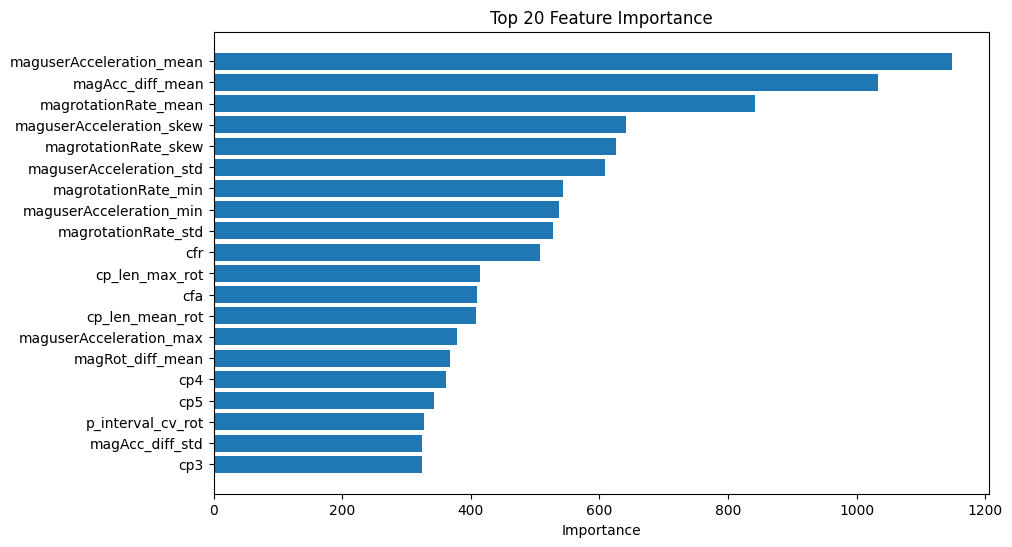

In [35]:
# 중요도 
feature_names = feature_cols

print("feature_names:", len(feature_names))
print("importances:", len(best_model.feature_importances_))

feature_names = feature_names[:len(best_model.feature_importances_)]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": best_model.feature_importances_
}).sort_values(by="importance", ascending=False)

# 중요도 상위 20개 시각화
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"][:20],
         feature_importance["importance"][:20])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")
plt.show()

## Group Kfold

In [36]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=gkf.split(X, y, groups),
        scoring="accuracy"
    )
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")
    
best_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_name]
best_model.fit(X_train, y_train)

print(f"\n최고 모델: {best_name} (정확도: {cv_scores[best_name]:.3f})")

RF: 0.846 (+/- 0.032)
XGB: 0.840 (+/- 0.037)
LGBM: 0.841 (+/- 0.037)

최고 모델: RF (정확도: 0.846)


In [37]:
# 필요한 평가 함수 불러오기
from sklearn.metrics import (
    accuracy_score,        # 정확도
    f1_score,              # F1-score
    classification_report,# 상세 리포트
    ConfusionMatrixDisplay
)

# 예측
y_pred = best_model.predict(X_test)

# 성능 계산
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

# 결과 출력
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1-Score: {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.813
Macro F1-Score: 0.819

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.47      0.61        15
           1       0.62      1.00      0.77        10
           2       1.00      0.90      0.95        10
           3       0.91      1.00      0.95        10
           4       0.78      0.93      0.85        15
           5       0.85      0.73      0.79        15

    accuracy                           0.81        75
   macro avg       0.84      0.84      0.82        75
weighted avg       0.84      0.81      0.80        75



## Hyperparameter Tuning

In [38]:
# warnings 무시
import warnings
warnings.filterwarnings("ignore")

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. 모델 정의
models = {
    "RF": (
        RandomForestClassifier(random_state=42),
        {
            # 트리 개수
            "n_estimators": [200, 300, 500],
            # 트리 깊이
            "max_depth": [None, 5, 10, 20],
            # 노드 분할 최소 샘플 수
            "min_samples_split": [2, 5, 10],
            # 리프 노드 최소 샘플 수
            "min_samples_leaf": [1, 2, 4],
            # 사용할 feature 개수 방식
            "max_features": ["sqrt", "log2"]
        }
    ),
    
    "XGB": (
        XGBClassifier(random_state=42, eval_metric="mlogloss"),
        {
            "n_estimators": [200, 300, 500],
            "max_depth": [3, 5, 7, 10],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }
    ),
    
    "LGBM": (
        LGBMClassifier(random_state=42, verbosity=-1),
        {
            "n_estimators": [200, 300, 500],
            "num_leaves": [31, 50, 100],
            "max_depth": [-1, 5, 10],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.8, 1.0],
            "colsample_bytree": [0.7, 0.8, 1.0]
        }
    )
}

# 2. 각 모델별 RandomizedSearchCV 실행
search_results = {}

for name, (model, param_grid) in models.items():
    print(f"\n{name} 튜닝 시작...")
    
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,              # 탐색할 파라미터 조합 개수 (속도 조절 가능)
        cv=3,                   # 3-fold 교차검증
        scoring="accuracy",     # 평가 지표
        n_jobs=1,              # 모든 CPU 사용
        random_state=42,
        verbose=1               # 진행 상황 출력
    )
    
    # 모델 학습 (이 안에서 cross validation 포함됨)
    search.fit(X_train, y_train)
    
    # 결과 저장
    search_results[name] = search
    
    # 최적 결과 출력
    print(f"{name} 최고 정확도: {search.best_score_:.3f}")
    print(f"{name} 최적 파라미터: {search.best_params_}")
    
# 가장 성능이 좋은 모델 선택
best_name = max(search_results, key=lambda x: search_results[x].best_score_)
best_search = search_results[best_name]
best_model = best_search.best_estimator_

print(f"\n최고 모델: {best_name}")
print(f"최고 CV 정확도: {best_search.best_score_:.3f}")
print(f"최적 파라미터: {best_search.best_params_}")



RF 튜닝 시작...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
RF 최고 정확도: 0.800
RF 최적 파라미터: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}

XGB 튜닝 시작...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
XGB 최고 정확도: 0.832
XGB 최적 파라미터: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}

LGBM 튜닝 시작...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
LGBM 최고 정확도: 0.832
LGBM 최적 파라미터: {'subsample': 0.7, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

최고 모델: XGB
최고 CV 정확도: 0.832
최적 파라미터: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [40]:
# 필요한 평가 함수 불러오기
from sklearn.metrics import (
    accuracy_score,        # 정확도
    f1_score,              # F1-score
    classification_report,# 상세 리포트
    ConfusionMatrixDisplay
)

# 예측
y_pred = best_model.predict(X_test)

# 성능 계산
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

# 결과 출력
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1-Score: {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.813
Macro F1-Score: 0.824

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.60      0.72        15
           1       0.59      1.00      0.74        10
           2       1.00      0.90      0.95        10
           3       0.91      1.00      0.95        10
           4       0.93      0.87      0.90        15
           5       0.71      0.67      0.69        15

    accuracy                           0.81        75
   macro avg       0.84      0.84      0.82        75
weighted avg       0.84      0.81      0.81        75



## Add Feature

In [41]:
# 1. feature 선택
feature_cols = [col for col in final_df.columns if col not in ['id', 'exp_no', 'activity']]

# 2. X, y 생성 (DataFrame / Series 유지)
X = final_df[feature_cols].copy()
y = final_df["activity"].copy()

# 3. interaction feature 추가
X["acc_rot_ratio"] = X["maguserAcceleration_mean"] / (X["magrotationRate_mean"] + 1e-5)
X["acc_rot_diff"] = X["maguserAcceleration_mean"] - X["magrotationRate_mean"]
X["acc_std_rot_std_ratio"] = X["maguserAcceleration_std"] / (X["magrotationRate_std"] + 1e-5)
X["acc_max_rot_max_ratio"] = X["maguserAcceleration_max"] / (X["magrotationRate_max"] + 1e-5)
X["acc_range"] = X["maguserAcceleration_max"] - X["maguserAcceleration_min"]
X["rot_range"] = X["magrotationRate_max"] - X["magrotationRate_min"]

print("추가된 feature 포함 전체 feature 개수:", X.shape[1])
# 4. 그룹 정의
groups = final_df["id"].astype(str)

# 5. 그룹별 정규화
X = X.groupby(groups).transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-5)
)

# 6. 라벨 인코딩
le = LabelEncoder()
y = le.fit_transform(y)

# 7. GroupShuffleSplit으로 학습/테스트 분할
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

# 8. iloc으로 행 선택
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# 9. 표준화 (선형 모델용일 때만 필요, 트리 모델은 보통 생략 가능)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

추가된 feature 포함 전체 feature 개수: 56
X_train shape: (285, 56)
X_test shape: (75, 56)


In [42]:
# 모델 불러오기
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 모델 정의
models = {
    'RF': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ),

    'XGB': XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method='hist',
        random_state=42
    ),

    'LGBM': LGBMClassifier(
        n_estimators=400,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity = -1
    )
}


In [43]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=gkf.split(X, y, groups),
        scoring="accuracy"
    )
    cv_scores[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")
    
best_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_name]
best_model.fit(X_train, y_train)

print(f"\n최고 모델: {best_name} (정확도: {cv_scores[best_name]:.3f})")

RF: 0.904 (+/- 0.053)
XGB: 0.893 (+/- 0.045)
LGBM: 0.908 (+/- 0.049)

최고 모델: LGBM (정확도: 0.908)


In [44]:
# 필요한 평가 함수 불러오기
from sklearn.metrics import (
    accuracy_score,        # 정확도
    f1_score,              # F1-score
    classification_report,# 상세 리포트
    ConfusionMatrixDisplay
)

# 예측
y_pred = best_model.predict(X_test)

# 성능 계산
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

# 결과 출력
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1-Score: {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.893
Macro F1-Score: 0.884

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        15
           1       1.00      1.00      1.00        10
           2       0.78      0.70      0.74        10
           3       0.73      0.80      0.76        10
           4       1.00      0.93      0.97        15
           5       1.00      0.87      0.93        15

    accuracy                           0.89        75
   macro avg       0.89      0.88      0.88        75
weighted avg       0.90      0.89      0.89        75



feature_names: 56
importances: 56


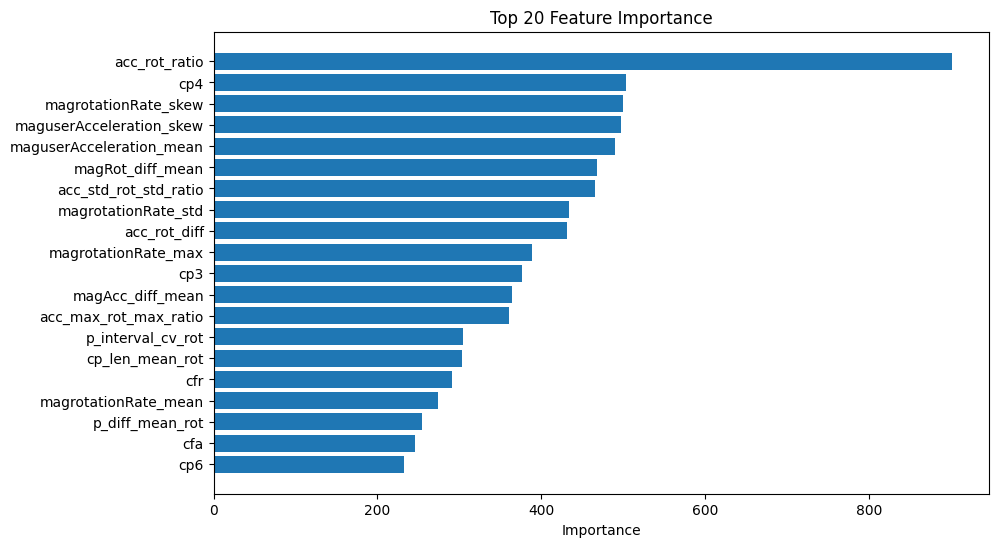

In [49]:
lgbm_model = models["LGBM"]
# feature 이름은 실제 학습 데이터 기준으로 가져와야 함
feature_names = X_train.columns

print("feature_names:", len(feature_names))
print("importances:", len(lgbm_model.feature_importances_))

# 중요도 DataFrame 생성
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm_model.feature_importances_
}).sort_values(by="importance", ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"][:20],
         feature_importance["importance"][:20])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")
plt.show()

## Soft Voting Ensemble

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import accuracy_score

# 1. 개별 모델 꺼내기
rf_model = models["RF"]
xgb_model = models["XGB"]
lgbm_model = models["LGBM"]

# 2. Soft Voting Ensemble 정의
ensemble_model = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("xgb", xgb_model),
        ("lgbm", lgbm_model)
    ],
    voting="soft"
)

# 3. 비교할 모델들 정리
all_models = {
    "RF": rf_model,
    "XGB": xgb_model,
    "LGBM": lgbm_model,
    "Ensemble": ensemble_model
}

# 4. train용 group 정보 따로 만들기
groups_train = groups.iloc[train_idx]

# 5. GroupKFold 설정
gkf = GroupKFold(n_splits=5)

# 6. KFold 평가 + test 평가
for name, model in all_models.items():
    # train 내부 GroupKFold
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=gkf.split(X_train, y_train, groups_train),
        scoring="accuracy",
        n_jobs=-1
    )

    # train 전체로 다시 학습
    model.fit(X_train, y_train)

    # test 평가
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"\n[{name}]")
    print(f"KFold 평균 정확도: {scores.mean():.3f} (+/- {scores.std():.3f})")
    print(f'Train 정확도     : {model.score(X_train, y_train):.3f}')
    print(f"Test 정확도      : {test_acc:.3f}")


[RF]
KFold 평균 정확도: 0.910 (+/- 0.043)
Train 정확도     : 1.000
Test 정확도      : 0.867

[XGB]
KFold 평균 정확도: 0.921 (+/- 0.025)
Train 정확도     : 1.000
Test 정확도      : 0.867

[LGBM]
KFold 평균 정확도: 0.914 (+/- 0.028)
Train 정확도     : 1.000
Test 정확도      : 0.893

[Ensemble]
KFold 평균 정확도: 0.921 (+/- 0.027)
Train 정확도     : 1.000
Test 정확도      : 0.893


# feature Importance만 사용하고 다시 학습

In [53]:
# =========================================
# 0. 필요한 라이브러리
# =========================================
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# =========================================
# 1. feature 선택
# =========================================
feature_cols = [col for col in final_df.columns if col not in ['id', 'exp_no', 'activity']]

# X, y 생성
X = final_df[feature_cols].copy()
y = final_df["activity"].copy()

# =========================================
# 2. feature engineering 추가
# =========================================
X["acc_rot_ratio"] = X["maguserAcceleration_mean"] / (X["magrotationRate_mean"] + 1e-5)
X["acc_rot_diff"] = X["maguserAcceleration_mean"] - X["magrotationRate_mean"]
X["acc_std_rot_std_ratio"] = X["maguserAcceleration_std"] / (X["magrotationRate_std"] + 1e-5)
X["acc_max_rot_max_ratio"] = X["maguserAcceleration_max"] / (X["magrotationRate_max"] + 1e-5)
X["acc_range"] = X["maguserAcceleration_max"] - X["maguserAcceleration_min"]
X["rot_range"] = X["magrotationRate_max"] - X["magrotationRate_min"]

print("추가된 feature 포함 전체 feature 개수:", X.shape[1])

# =========================================
# 3. 그룹 정의
# =========================================
groups = final_df["id"].astype(str)

# =========================================
# 4. 그룹별 정규화
# =========================================
X = X.groupby(groups).transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-5)
)

# =========================================
# 5. 라벨 인코딩
# =========================================
le = LabelEncoder()
y = le.fit_transform(y)

# =========================================
# 6. GroupShuffleSplit으로 train / test 분리
# =========================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

groups_train = groups.iloc[train_idx]

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

# =========================================
# 7. 모델 정의 (과적합 완화용)
# =========================================
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    eval_metric="mlogloss"
)

lgbm_model = LGBMClassifier(
    n_estimators=100,
    num_leaves=7,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=20,
    min_split_gain=0.1,
    random_state=42,
    verbosity=-1
)

ensemble_model = VotingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("lgbm", lgbm_model)
    ],
    voting="soft",
    weights=[1, 2]
)

# =========================================
# 8. 우선 전체 feature로 학습해서 중요도 계산
#    (단일 모델 기준으로 중요도 계산)
# =========================================
lgbm_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(feature_importance.head(20))

# =========================================
# 9. top feature 선택
#    처음에는 15개로 시작
# =========================================
top_features = feature_importance["feature"].head(15).tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

print("선택된 top feature 개수:", len(top_features))
print(top_features)

# =========================================
# 10. GroupKFold 평가
# =========================================
gkf = GroupKFold(n_splits=5)

cv_scores = cross_val_score(
    ensemble_model,
    X_train_top,
    y_train,
    cv=gkf.split(X_train_top, y_train, groups_train),
    scoring="accuracy",
    n_jobs=1
)

print("GroupKFold 정확도들:", np.round(cv_scores, 3))
print(f"GroupKFold 평균 정확도: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# =========================================
# 11. train 전체로 최종 학습
# =========================================
ensemble_model.fit(X_train_top, y_train)

# =========================================
# 12. train / test 최종 평가
# =========================================
train_acc = ensemble_model.score(X_train_top, y_train)
test_acc = ensemble_model.score(X_test_top, y_test)

print(f"Train 정확도: {train_acc:.3f}")
print(f"Test 정확도 : {test_acc:.3f}")

추가된 feature 포함 전체 feature 개수: 56
X_train shape: (285, 56)
X_test shape : (75, 56)


,feature,importance
50,acc_rot_ratio,178
0,maguserAcceleration_mean,138
41,cp4,121
12,magRot_diff_mean,112
51,acc_rot_diff,98
52,acc_std_rot_std_ratio,90
9,magrotationRate_skew,89
4,maguserAcceleration_skew,81
8,magrotationRate_std,78
10,magAcc_diff_mean,70


선택된 top feature 개수: 15
['acc_rot_ratio', 'maguserAcceleration_mean', 'cp4', 'magRot_diff_mean', 'acc_rot_diff', 'acc_std_rot_std_ratio', 'magrotationRate_skew', 'maguserAcceleration_skew', 'magrotationRate_std', 'magAcc_diff_mean', 'cfr', 'cp6', 'magrotationRate_mean', 'cp_len_mean_rot', 'cp_len_max_rot']
GroupKFold 정확도들: [0.883 0.933 0.917 0.933 0.889]
GroupKFold 평균 정확도: 0.911 (+/- 0.021)
Train 정확도: 0.989
Test 정확도 : 0.853


In [54]:
feature_importance.head(26)

,feature,importance
50,acc_rot_ratio,178
0,maguserAcceleration_mean,138
41,cp4,121
12,magRot_diff_mean,112
51,acc_rot_diff,98
52,acc_std_rot_std_ratio,90
9,magrotationRate_skew,89
4,maguserAcceleration_skew,81
8,magrotationRate_std,78
10,magAcc_diff_mean,70


In [55]:
# 중요도 상위 20개 feature 선택
top_features = feature_importance["feature"].head(26).tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# ensemble 정의
ensemble_model = VotingClassifier(
    estimators=[
        ("rf", models["RF"]),
        ("xgb", models["XGB"]),
        ("lgbm", models["LGBM"])
    ],
    voting="soft"
)

# train 데이터에 해당하는 group 정보
groups_train = groups.iloc[train_idx]

# GroupKFold 설정
gkf = GroupKFold(n_splits=5)

# train 내부에서만 교차검증
cv_scores = cross_val_score(
    ensemble_model,
    X_train_top,
    y_train,
    cv=gkf.split(X_train_top, y_train, groups_train),
    scoring="accuracy",
    n_jobs=-1
)

print("GroupKFold 정확도들:", np.round(cv_scores, 3))
print(f"GroupKFold 평균 정확도: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

# train 전체로 최종 학습
ensemble_model.fit(X_train_top, y_train)

# test는 최종 평가만
train_acc = ensemble_model.score(X_train_top, y_train)
test_acc = ensemble_model.score(X_test_top, y_test)

print(f"Train 정확도: {train_acc:.3f}")
print(f"Test 정확도 : {test_acc:.3f}")

GroupKFold 정확도들: [0.883 0.9   0.933 0.95  0.889]
GroupKFold 평균 정확도: 0.911 (+/- 0.026)
Train 정확도: 1.000
Test 정확도 : 0.920


              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      1.00      1.00        10
           2       0.80      0.80      0.80        10
           3       0.80      0.80      0.80        10
           4       1.00      1.00      1.00        15
           5       1.00      0.87      0.93        15

    accuracy                           0.92        75
   macro avg       0.91      0.91      0.91        75
weighted avg       0.92      0.92      0.92        75

[[15  0  0  0  0  0]
 [ 0 10  0  0  0  0]
 [ 0  0  8  2  0  0]
 [ 0  0  2  8  0  0]
 [ 0  0  0  0 15  0]
 [ 2  0  0  0  0 13]]


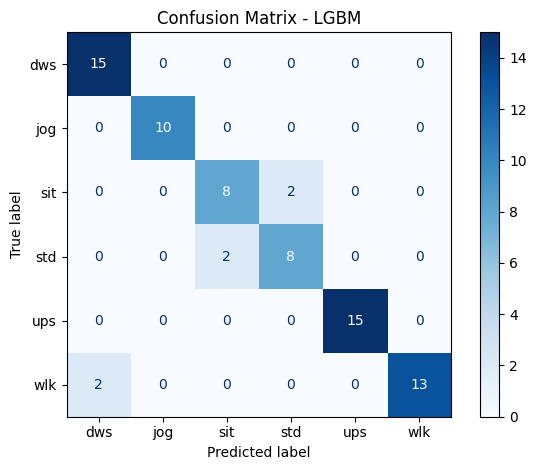

In [56]:
from sklearn.metrics import confusion_matrix, classification_report

top_features = feature_importance["feature"].head(26).tolist()

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

ensemble_model.fit(X_train_top, y_train)
y_pred = ensemble_model.predict(X_test_top)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Confusion Matrix 시각화
ConfusionMatrixDisplay.from_estimator(
    ensemble_model,
    X_test_top,
    y_test,
    display_labels=le.classes_,   # 라벨 이름 표시  
    cmap="Blues"
)

plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

# model과 feature 줄이기 (테스트용)

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models_small = {
    "XGB": XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.5,
        random_state=42,
        eval_metric="mlogloss"
    ),
    "LGBM": LGBMClassifier(
        n_estimators=200,
        num_leaves=15,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=10,
        random_state=42,
        verbosity=-1
    )
}

In [48]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np

groups_train = groups.iloc[train_idx]
gkf = GroupKFold(n_splits=5)

results = []

for k in [5, 8, 10, 12, 15, 18, 20,25,26,27,30]:
    top_features = feature_importance["feature"].head(k).tolist()
    X_train_k = X_train[top_features]
    X_test_k = X_test[top_features]

    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1.0,
        reg_lambda=2.0,
        random_state=42,
        eval_metric="mlogloss"
    )

    lgbm_model = LGBMClassifier(
        n_estimators=100,
        num_leaves=7,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.7,
        colsample_bytree=0.7,
        min_child_samples=20,
        min_split_gain=0.1,
        random_state=42,
        verbosity=-1
    )

    ensemble_model = VotingClassifier(
        estimators=[
            ("xgb", xgb_model),
            ("lgbm", lgbm_model)
        ],
        voting="soft",
        weights=[1, 2]
    )

    cv_scores = cross_val_score(
        ensemble_model,
        X_train_k,
        y_train,
        cv=gkf.split(X_train_k, y_train, groups_train),
        scoring="accuracy",
        n_jobs=1
    )

    ensemble_model.fit(X_train_k, y_train)
    test_acc = ensemble_model.score(X_test_k, y_test)

    results.append({
        "top_k": k,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "test_acc": test_acc
    })

results_df = pd.DataFrame(results).sort_values(by="test_acc", ascending=False)
display(results_df)

,top_k,cv_mean,cv_std,test_acc
6,20,0.918889,0.016704,0.866667
3,12,0.896667,0.026667,0.853333
4,15,0.911111,0.021373,0.853333
5,18,0.917778,0.022055,0.853333
7,25,0.917778,0.022055,0.853333
8,26,0.911111,0.015316,0.853333
9,27,0.911111,0.015316,0.853333
10,30,0.911111,0.015316,0.853333
1,8,0.852222,0.028889,0.840000
2,10,0.881111,0.016704,0.840000
